In [1]:
!pip install langchain_groq

In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict

In [ ]:
import os

os.environ["GROQ_API_KEY"] = ""

In [4]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

model = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=GROQ_API_KEY
)

In [11]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [12]:
def create_outline(state: BlogState) -> BlogState:

    title = state['title']

    prompt = f'generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

In [17]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(prompt).content
    state['content'] = content

    return state

In [18]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

workflow = graph.compile()

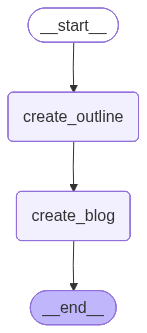

In [19]:
workflow

In [20]:
initial_state = {"title":"Rise of AI in India"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in India', 'outline': '**Blog Title:** *The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*  \n\n**Target Audience:** Tech enthusiasts, policymakers, entrepreneurs, students, investors, and anyone interested in how artificial intelligence is reshaping India’s economy and society.  \n\n---\n\n## 1. Introduction  \n- **Hook:** A striking statistic or anecdote (e.g., “India’s AI market is projected to reach **$17\u202fbillion** by 2027, outpacing many developed economies.”)  \n- **Why It Matters:** Briefly explain AI’s global impact and why India’s trajectory is uniquely significant (large talent pool, digital leapfrogging, demographic dividend).  \n- **Purpose of the Post:** Outline what readers will learn—historical context, current landscape, key drivers, sectoral use‑cases, challenges, policy environment, and future outlook.  \n\n---\n\n## 2. Historical Context: From Early Experiments to a National Mission  \n### 2.1 Early Foundations (1990s‑2

In [22]:
print(final_state['outline'])

**Blog Title:** *The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*  

**Target Audience:** Tech enthusiasts, policymakers, entrepreneurs, students, investors, and anyone interested in how artificial intelligence is reshaping India’s economy and society.  

---

## 1. Introduction  
- **Hook:** A striking statistic or anecdote (e.g., “India’s AI market is projected to reach **$17 billion** by 2027, outpacing many developed economies.”)  
- **Why It Matters:** Briefly explain AI’s global impact and why India’s trajectory is uniquely significant (large talent pool, digital leapfrogging, demographic dividend).  
- **Purpose of the Post:** Outline what readers will learn—historical context, current landscape, key drivers, sectoral use‑cases, challenges, policy environment, and future outlook.  

---

## 2. Historical Context: From Early Experiments to a National Mission  
### 2.1 Early Foundations (1990s‑2000s)  
- Academic research hubs (IITs, ISI, IISc) and the first

In [23]:
print(final_state['content'])

**Blog Title:**  
*The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*  

**Target Audience:** Tech enthusiasts, policymakers, entrepreneurs, students, investors, and anyone curious about how artificial intelligence is reshaping India’s economy and society.  

---  

## 1. Introduction  

**Hook** – *“India’s AI market is projected to reach **$17 billion** by 2027, outpacing many developed economies.”*  

Artificial intelligence is no longer a futuristic buzz‑word; it is the engine that is already redefining health, finance, agriculture, education, and public services worldwide. For India, the stakes are uniquely high. With a **1.4 bn‑strong population**, a **demographic dividend of 65 % under 35**, and a **mobile‑first digital ecosystem**, the country sits at the crossroads of a massive talent pool and an unprecedented data tsunami.  

**What you’ll get from this post**  

- A quick tour of AI’s historical evolution in India.  
- The macro‑drivers that have turned 